<a href="https://colab.research.google.com/github/mirzatairin/HWO-Spectral-Modeling/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

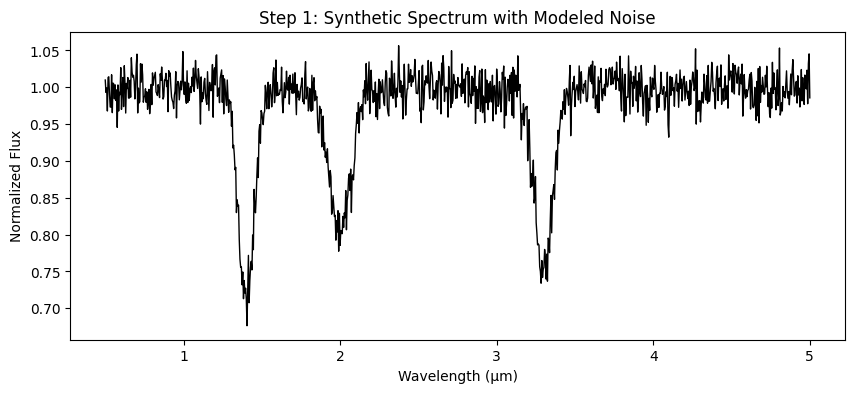

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# --- 1. SETUP: Defining the Spectral Range ---
# I am creating a wavelength range from 0.5 to 5.0 micrometers (near-infrared).
# This is a key region for finding biosignatures like Water and Methane.
wavelength = np.linspace(0.5, 5, 1000)
flux = np.ones_like(wavelength) # Starting with a clean baseline (unfiltered light)

# --- 2. THE GAUSSIAN MODEL: Simulating Absorption ---
def add_absorption_feature(center, depth, width):
    """
    I use a Gaussian profile here because it naturally models
    the 'blurring' of molecular absorption lines in real-world data.
    """
    # Formula: 1 - [Bell Curve Shape]
    # At the 'center', the absorption is deepest.
    return 1 - depth * np.exp(-0.5 * ((wavelength - center)/width)**2)

# Applying molecular 'fingerprints' based on known spectral references
flux *= add_absorption_feature(1.4, 0.3, 0.05)  # Water (H2O)
flux *= add_absorption_feature(2.0, 0.2, 0.07)  # Carbon Dioxide (CO2)
flux *= add_absorption_feature(3.3, 0.25, 0.06) # Methane (CH4)

# --- 3. SIGNAL DEGRADATION: Adding Instrument Noise ---
# In reality, telescopes aren't perfect. I'm adding Gaussian noise
# to test if my detection algorithm can handle 'messy' data.
noise_level = 0.02
flux += np.random.normal(0, noise_level, len(wavelength))

plt.figure(figsize=(10, 4))
plt.plot(wavelength, flux, color='black', linewidth=1)
plt.title("Step 1: Synthetic Spectrum with Modeled Noise")
plt.xlabel("Wavelength (μm)")
plt.ylabel("Normalized Flux")
plt.show()

In [2]:
# --- 4. SIGNAL PROCESSING: Peak Detection ---
# Since absorption is a 'dip', I invert the signal (-flux)
# so the computer can find them as 'peaks'.
# I set 'prominence' to filter out the small wiggles caused by noise.
detection_threshold = -0.95
sensitivity = 0.15

peaks, _ = find_peaks(-flux, height=detection_threshold, prominence=sensitivity)
detected_wavelengths = wavelength[peaks]

# --- 5. IDENTIFICATION: Matching Detections to Catalog ---
# A reference dictionary of molecules relevant to habitability.
biosignature_catalog = {
    "H2O": 1.4,
    "CO2": 2.0,
    "CH4": 3.3
}

def identify_biosignatures(detected_list):
    identified = []
    # I allow for a small 'tolerance' (0.1 μm) because noise can shift the center.
    tolerance = 0.1

    for name, reference_point in biosignature_catalog.items():
        for d in detected_list:
            if abs(d - reference_point) < tolerance:
                identified.append(name)
    return list(set(identified))

found_molecules = identify_biosignatures(detected_wavelengths)
print(f"Algorithm Findings: {found_molecules}")

Algorithm Findings: ['H2O', 'CH4', 'CO2']


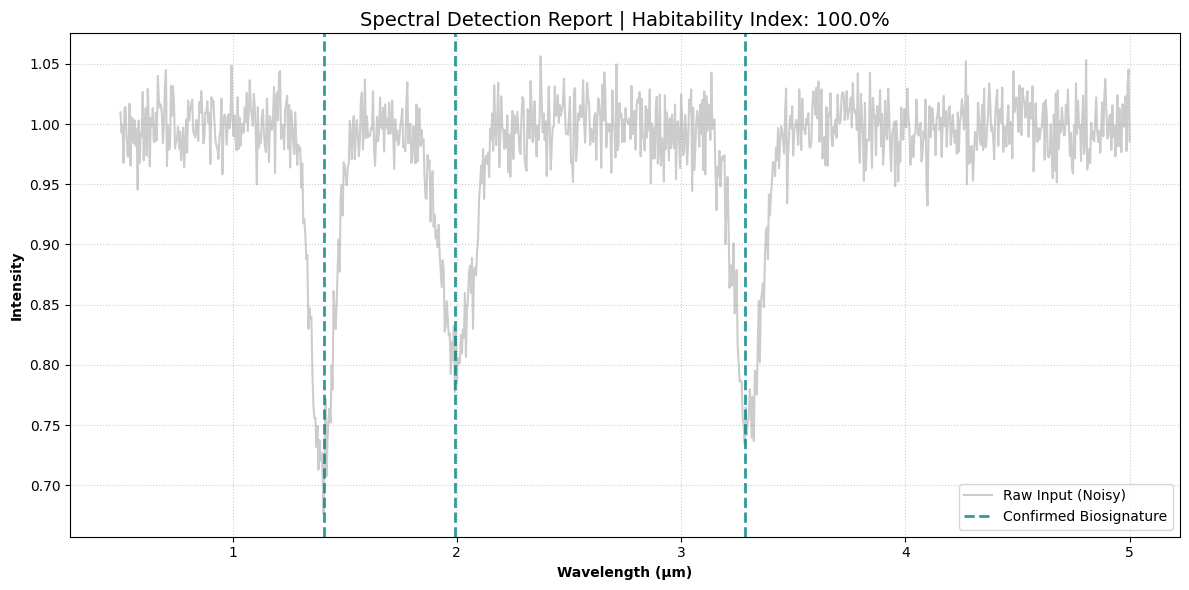

Final Assessment: 3 of 3 molecules detected.


In [3]:
# --- 6. METRICS: Calculating Habitability Score ---
def calculate_habitability_index(detected_mols):
    # This represents a simplified probability based on our targets.
    total_targets = len(biosignature_catalog)
    return len(detected_mols) / total_targets

score = calculate_habitability_index(found_molecules)

# --- 7. FINAL VISUALIZATION ---
plt.figure(figsize=(12, 6))

# Plotting the raw noisy signal in the background
plt.plot(wavelength, flux, color='gray', alpha=0.4, label="Raw Input (Noisy)")

# Marking my algorithm's detections
for i, peak_val in enumerate(detected_wavelengths):
    label = "Confirmed Biosignature" if i == 0 else ""
    plt.axvline(x=peak_val, color='teal', linestyle='--', linewidth=2, alpha=0.8, label=label)

# Styling for a professional 'NASA' look
plt.title(f"Spectral Detection Report | Habitability Index: {score:.1%}", fontsize=14)
plt.xlabel("Wavelength (μm)", fontweight='bold')
plt.ylabel("Intensity", fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Final Assessment: {len(found_molecules)} of {len(biosignature_catalog)} molecules detected.")